# GD05 — Seq2Seq 한국어→영어 번역기
**Bahdanau Attention 기반 GRU Encoder-Decoder 모델**

| 항목 | 내용 |
|------|------|
| 프로젝트명 | GD05 한영 번역기 |
| 모델 | Bahdanau Attention Seq2Seq (GRU) |
| 데이터 | korean-parallel-corpora (jungyeul) |
| 한국어 토크나이저 | KoNLPy MeCab |


## 0. 환경 설치
터미널 또는 셀에서 한 번만 실행하세요.

In [1]:
!sudo apt-get update -q
!sudo apt-get install -y fonts-nanum mecab mecab-ko mecab-ko-dic
!pip install konlpy JPype1 nbformat -q


Hit:1 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:2 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists...
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package mecab-ko
E: Unable to locate package mecab-ko-dic


## 1. 라이브러리 Import & 버전 확인

In [2]:
import os, re, tarfile, urllib.request, random, logging
import numpy as np
import pandas as pd
import pandas
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# 한국어 폰트 설정
fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = None
if os.path.exists(fontpath):
    fontprop = fm.FontProperties(fname=fontpath, size=12)
    plt.rcParams["font.family"] = fontprop.get_name()
    print(f"설정된 폰트: {fontprop.get_name()}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")
print(f"pandas  : {pandas.__version__}")
print(f"torch   : {torch.__version__}")
print(f"matplotlib: {matplotlib.__version__}")


설정된 폰트: NanumBarunGothic
사용 디바이스: cuda
pandas  : 2.3.0
torch   : 2.7.1+cu118
matplotlib: 3.10.3


## Step 1. 데이터 다운로드
`jungyeul/korean-parallel-corpora` 저장소에서 한영 병렬 말뭉치를 내려받습니다.

In [3]:
DATA_DIR = os.path.expanduser("~/work/kor_eng_translation")
os.makedirs(DATA_DIR, exist_ok=True)

TAR_URL  = ("https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/"
            "master/korean-english-news-v1/korean-english-park.train.tar.gz")
TAR_PATH = os.path.join(DATA_DIR, "korean-english-park.train.tar.gz")

if not os.path.exists(TAR_PATH):
    print("데이터 다운로드 중...")
    urllib.request.urlretrieve(TAR_URL, TAR_PATH)
    print("다운로드 완료!")
else:
    print("이미 다운로드됨:", TAR_PATH)

EXTRACT_DIR = os.path.join(DATA_DIR, "extracted")
os.makedirs(EXTRACT_DIR, exist_ok=True)
if not os.listdir(EXTRACT_DIR):
    print("압축 해제 중...")
    with tarfile.open(TAR_PATH, "r:gz") as tar:
        tar.extractall(EXTRACT_DIR)
    print("압축 해제 완료!")

en_file, ko_file = None, None
for root, dirs, files in os.walk(EXTRACT_DIR):
    for f in files:
        if f.endswith(".en"):
            en_file = os.path.join(root, f)
        elif f.endswith(".ko"):
            ko_file = os.path.join(root, f)
print("영어 파일:", en_file)
print("한국어 파일:", ko_file)

with open(en_file, encoding="utf-8") as f:
    en_lines = [l.strip() for l in f.readlines()]
with open(ko_file, encoding="utf-8") as f:
    ko_lines = [l.strip() for l in f.readlines()]

print(f"\n원본 문장 수: {len(en_lines):,}")
print("샘플 영어:", en_lines[0])
print("샘플 한국어:", ko_lines[0])


이미 다운로드됨: /home/jovyan/work/kor_eng_translation/korean-english-park.train.tar.gz
영어 파일: /home/jovyan/work/kor_eng_translation/extracted/korean-english-park.train.en
한국어 파일: /home/jovyan/work/kor_eng_translation/extracted/korean-english-park.train.ko

원본 문장 수: 94,123
샘플 영어: Much of personal computing is about "can you top this?"
샘플 한국어: 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"


## Step 2. 데이터 정제
- **중복 제거**: `(영어, 한국어)` 쌍을 `set`에 넣어 병렬 쌍이 깨지지 않도록 처리
- **한국어 정규식**: `[^ ㄱ-ㅎㅏ-ㅣ가-힣a-zA-Z0-9?.!,]+` — 한글 자모·완성형, 영문, 숫자, 구두점만 유지
- **영어 정규식**: 소문자화 + 구두점 분리


In [4]:
def preprocess_english(sentence):
    """영어 전처리: 소문자, 구두점 분리, 공백 정리"""
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)
    return sentence.strip()


def preprocess_korean(sentence):
    """한국어 전처리: 한글·영문·숫자·구두점만 유지, 공백 정리"""
    sentence = sentence.strip()
    sentence = re.sub(r"[^ ㄱ-ㅎㅏ-ㅣ가-힣a-zA-Z0-9?.!,]+", " ", sentence)
    sentence = re.sub(r'[ ]+', " ", sentence)
    return sentence.strip()


en_proc = [preprocess_english(s) for s in en_lines]
ko_proc = [preprocess_korean(s)  for s in ko_lines]

# set을 활용한 중복 제거 (쌍 유지)
seen = set()
cleaned_corpus = []
for en, ko in zip(en_proc, ko_proc):
    pair = (en, ko)
    if pair not in seen and en and ko:
        seen.add(pair)
        cleaned_corpus.append(pair)

print(f"원본: {len(en_lines):,}  →  중복 제거 후: {len(cleaned_corpus):,}")
print("샘플:", cleaned_corpus[0])


원본: 94,123  →  중복 제거 후: 78,918
샘플: ('much of personal computing is about can you top this ?', '개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐?')


## Step 3. 형태소 분석 & 토큰 길이 필터링
- 한국어: **KoNLPy MeCab** `morphs()` (미설치 시 공백 split fallback)
- 영어: 공백 split 후 `<start>` / `<end>` 토큰 추가
- 토큰 길이 **40 이하**인 문장만 사용


In [5]:
try:
    from konlpy.tag import Mecab
    mecab = Mecab()
    def tokenize_korean(sentence):
        return mecab.morphs(sentence)
    print("✅ MeCab 사용")
except Exception as e:
    print(f"⚠️  MeCab 미설치 ({e}) → 공백 split 사용")
    def tokenize_korean(sentence):
        return sentence.split()

MAX_LEN = 40

kor_corpus, eng_corpus = [], []
for en, ko in cleaned_corpus:
    ko_tokens = tokenize_korean(ko)
    en_tokens = en.split()
    if len(ko_tokens) <= MAX_LEN and len(en_tokens) <= MAX_LEN:
        kor_corpus.append(ko_tokens)
        eng_corpus.append(["<start>"] + en_tokens + ["<end>"])

print(f"필터링 후 문장 수: {len(eng_corpus):,}")
print("한국어 샘플:", kor_corpus[0])
print("영어 샘플  :", eng_corpus[0])


⚠️  MeCab 미설치 (Install MeCab in order to use it: http://konlpy.org/en/latest/install/) → 공백 split 사용
필터링 후 문장 수: 72,125
한국어 샘플: ['개인용', '컴퓨터', '사용의', '상당', '부분은', '이것보다', '뛰어날', '수', '있느냐?']
영어 샘플  : ['<start>', 'much', 'of', 'personal', 'computing', 'is', 'about', 'can', 'you', 'top', 'this', '?', '<end>']


## Step 4. 단어 사전(Vocab) 구축
- `<pad>=0`, `<unk>=1` 고정
- 한국어: 최소 빈도 2 이상, 영어: 빈도 1 이상 (특수 토큰 포함)
- vocab 크기 최소 10,000 이상 확보


In [6]:
from collections import Counter

MIN_FREQ = 2

def build_vocab(corpus, min_freq=2, special_tokens=None):
    counter = Counter(tok for sent in corpus for tok in sent)
    vocab = {"<pad>": 0, "<unk>": 1}
    idx = 2
    if special_tokens:
        for tok in special_tokens:
            if tok not in vocab:
                vocab[tok] = idx; idx += 1
    for word, freq in counter.most_common():
        if freq >= min_freq and word not in vocab:
            vocab[word] = idx; idx += 1
    return vocab

kor_vocab = build_vocab(kor_corpus, min_freq=MIN_FREQ)
eng_vocab = build_vocab(eng_corpus, min_freq=1, special_tokens=["<start>", "<end>"])

idx2eng = {v: k for k, v in eng_vocab.items()}
idx2kor = {v: k for k, v in kor_vocab.items()}

print(f"한국어 vocab 크기: {len(kor_vocab):,}")
print(f"영어   vocab 크기: {len(eng_vocab):,}")

def encode(tokens, vocab, max_len=MAX_LEN + 2):
    ids = [vocab.get(t, vocab["<unk>"]) for t in tokens]
    ids = ids[:max_len]
    ids += [vocab["<pad>"]] * (max_len - len(ids))
    return ids


한국어 vocab 크기: 76,849
영어   vocab 크기: 41,748


## Step 5. Dataset / DataLoader 구성

In [7]:
class TranslationDataset(Dataset):
    def __init__(self, kor_corpus, eng_corpus, kor_vocab, eng_vocab, max_len):
        self.src       = [encode(k,      kor_vocab, max_len) for k in kor_corpus]
        self.trg_input = [encode(e[:-1], eng_vocab, max_len) for e in eng_corpus]  # <start>…
        self.trg_label = [encode(e[1:],  eng_vocab, max_len) for e in eng_corpus]  # …<end>

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        return (torch.tensor(self.src[idx]),
                torch.tensor(self.trg_input[idx]),
                torch.tensor(self.trg_label[idx]))

BATCH_SIZE = 64
dataset      = TranslationDataset(kor_corpus, eng_corpus, kor_vocab, eng_vocab, max_len=MAX_LEN + 2)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

for src, trg_in, trg_lb in train_loader:
    print("src shape      :", src.shape)
    print("trg_input shape:", trg_in.shape)
    print("trg_label shape:", trg_lb.shape)
    break


src shape      : torch.Size([64, 42])
trg_input shape: torch.Size([64, 42])
trg_label shape: torch.Size([64, 42])


## Step 6. 모델 설계 — Bahdanau Attention Seq2Seq

```
Encoder (GRU)  →  모든 H 출력
Bahdanau Attention  →  score(s_{t-1}, H)  →  softmax  →  context vector
Decoder (GRU)  →  embed + GRU  →  cat(s_t, context)  →  FC  →  ŷ_t
```


In [8]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v  = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden         : (batch, hidden)
        # encoder_outputs: (src_len, batch, hidden)
        src_len = encoder_outputs.shape[0]
        hidden  = hidden.unsqueeze(1).repeat(1, src_len, 1)
        enc_out = encoder_outputs.permute(1, 0, 2)
        energy  = torch.tanh(self.W1(enc_out) + self.W2(hidden))
        attn    = self.v(energy).squeeze(2)
        return nn.functional.softmax(attn, dim=1)


class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.rnn       = nn.GRU(emb_dim, hidden_dim)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, src):
        embedded        = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden


class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, attention, dropout=0.3):
        super().__init__()
        self.attention = attention
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.rnn       = nn.GRU(emb_dim, hidden_dim)
        self.fc_out    = nn.Linear(hidden_dim * 2, vocab_size)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs):
        input    = input.unsqueeze(0)
        embedded = self.dropout(self.embedding(input))

        a        = self.attention(hidden[-1], encoder_outputs).unsqueeze(1)
        enc_out  = encoder_outputs.permute(1, 0, 2)
        context  = torch.bmm(a, enc_out).permute(1, 0, 2)

        output, hidden = self.rnn(embedded, hidden)
        output  = output.squeeze(0)
        context = context.squeeze(0)
        pred    = self.fc_out(torch.cat([output, context], dim=1))
        return pred, hidden, a.squeeze(1)


class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, trg=None, max_len=42, bos_id=None, eos_id=None):
        batch_size = src.shape[1]
        outputs, attentions = [], []
        enc_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(trg.shape[0]):
                out, hidden, attn = self.decoder(trg[t], hidden, enc_outputs)
                outputs.append(out.unsqueeze(0))
                attentions.append(attn.unsqueeze(0))
        else:
            inp      = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)
            for _ in range(max_len):
                out, hidden, attn = self.decoder(inp, hidden, enc_outputs)
                outputs.append(out.unsqueeze(0))
                attentions.append(attn.unsqueeze(0))
                top1      = out.argmax(1)
                inp       = top1
                finished |= (top1 == eos_id)
                if finished.all(): break

        return torch.cat(outputs, 0), torch.cat(attentions, 0)


# 하이퍼파라미터
EMB_DIM    = 256
HIDDEN_DIM = 512
DROPOUT    = 0.3

encoder   = Encoder(len(kor_vocab), EMB_DIM, HIDDEN_DIM, DROPOUT).to(device)
attention = BahdanauAttention(HIDDEN_DIM).to(device)
decoder   = Decoder(len(eng_vocab), EMB_DIM, HIDDEN_DIM, attention, DROPOUT).to(device)
model     = Seq2SeqAttention(encoder, decoder, device).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\n총 학습 가능 파라미터: {total_params:,}")


Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(76849, 256, padding_idx=0)
    (rnn): GRU(256, 512)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(41748, 256, padding_idx=0)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=41748, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)

총 학습 가능 파라미터: 76,043,796


## Step 7. 훈련 함수 & 추론 함수 정의
- `CrossEntropyLoss(ignore_index=PAD_ID)` — PAD 토큰 loss 무시
- `clip_grad_norm_(1.0)` — gradient exploding 방지
- `ReduceLROnPlateau` — loss 정체 시 학습률 자동 감소


In [9]:
PAD_ID = kor_vocab["<pad>"]
BOS_ID = eng_vocab["<start>"]
EOS_ID = eng_vocab["<end>"]

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

TEST_SENTENCES = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
]


def train_step(model, loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}", leave=True)
    for src, trg_in, trg_lb in pbar:
        src    = src.permute(1, 0).to(device)
        trg_in = trg_in.permute(1, 0).to(device)
        trg_lb = trg_lb.permute(1, 0).to(device)
        optimizer.zero_grad()
        outputs, _ = model(src, trg_in)
        loss = criterion(outputs.reshape(-1, outputs.shape[-1]), trg_lb.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    return epoch_loss / len(loader)


def evaluate_sentence(sentence, model, max_len=MAX_LEN + 2):
    model.eval()
    sentence = preprocess_korean(sentence)
    tokens   = tokenize_korean(sentence)
    ids      = encode(tokens, kor_vocab, max_len)
    src      = torch.tensor(ids).unsqueeze(1).to(device)
    with torch.no_grad():
        outputs, attentions = model(src, max_len=max_len, bos_id=BOS_ID, eos_id=EOS_ID)
    result = []
    for idx in outputs.argmax(2).squeeze(1).tolist():
        word = idx2eng.get(idx, "<unk>")
        result.append(word)
        if word == "<end>": break
    return " ".join(result), tokens, attentions.squeeze(1).cpu().numpy()


def show_attention(sentence, translation, src_tokens, attention, epoch):
    trg_tokens = translation.split()
    attn_map   = attention[:len(trg_tokens), :len(src_tokens)]
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.matshow(attn_map, cmap="viridis")
    plt.colorbar(im, ax=ax)
    fp = fontprop if fontprop else None
    ax.set_xticklabels([""] + src_tokens, rotation=45, ha="left", fontproperties=fp)
    ax.set_yticklabels([""] + trg_tokens)
    ax.set_xlabel("Source (한국어)")
    ax.set_ylabel("Target (영어)")
    ax.set_title(f"Attention Map | Epoch {epoch}\n입력: {sentence}")
    plt.tight_layout()
    save_path = os.path.join(DATA_DIR, f"attention_epoch{epoch}.png")
    plt.savefig(save_path, dpi=100)
    plt.show()
    print(f"Attention Map 저장: {save_path}")

print("슝~")


슝~


## Step 8. 훈련 시작
매 에폭마다 예문 4개를 번역하여 출력합니다. 가장 좋은 결과의 에폭을 제출하세요.

Epoch 1: 100%|██████████| 1127/1127 [10:24<00:00,  1.81it/s, loss=5.1440]



[Epoch 1/30]  Train Loss: 5.7189
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama s campaign , obama leads , obama s campaign , said obama . <end>
  입력: 시민들은 도시 속에 산다.
  번역: the ap s mark smith is the first time in the first half of the year . <end>
  입력: 커피는 필요 없다.
  번역: the dow jones industrial average points . <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: the two men were killed in the blast . <end>
--------------------------------------------------


Epoch 2: 100%|██████████| 1127/1127 [10:24<00:00,  1.80it/s, loss=4.6646]



[Epoch 2/30]  Train Loss: 4.7058
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama s campaign is going to be a big problem . <end>
  입력: 시민들은 도시 속에 산다.
  번역: the ap s mark smith has been a little bit of the country s pacifist . <end>
  입력: 커피는 필요 없다.
  번역: the ap s mark smith is now <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: the attacker was killed in a suicide bombing in the town of areopolis , killing people and wounding . <end>
--------------------------------------------------


Epoch 3: 100%|██████████| 1127/1127 [10:25<00:00,  1.80it/s, loss=4.3498]



[Epoch 3/30]  Train Loss: 4.0977
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama s campaign won t be trusted . <end>
  입력: 시민들은 도시 속에 산다.
  번역: the ap s mark lavie reports that the couple s name is a good thing . <end>
  입력: 커피는 필요 없다.
  번역: i m going to be a little bit of redemption . <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: thousands of people were killed in the blast . <end>
--------------------------------------------------


Epoch 4: 100%|██████████| 1127/1127 [10:26<00:00,  1.80it/s, loss=3.6835]



[Epoch 4/30]  Train Loss: 3.6655
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama s campaign was campaigning in the overall delegate count . <end>
  입력: 시민들은 도시 속에 산다.
  번역: the pair of the bridge caved . <end>
  입력: 커피는 필요 없다.
  번역: we re not going to be a little bit . <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: the death toll from the blast killed people . <end>
--------------------------------------------------


Epoch 5: 100%|██████████| 1127/1127 [10:25<00:00,  1.80it/s, loss=3.5954]
/tmp/ipykernel_756/2099579019.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""] + src_tokens, rotation=45, ha="left", fontproperties=fp)
/tmp/ipykernel_756/2099579019.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + trg_tokens)



[Epoch 5/30]  Train Loss: 3.3859
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama has personally courting the economy , obama said . <end>
  입력: 시민들은 도시 속에 산다.
  번역: the ap s mark smith has been trying to lure the nation s psyche . <end>
  입력: 커피는 필요 없다.
  번역: i don t think that is anything . <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: thousands of people have been killed in the clashes . <end>
--------------------------------------------------


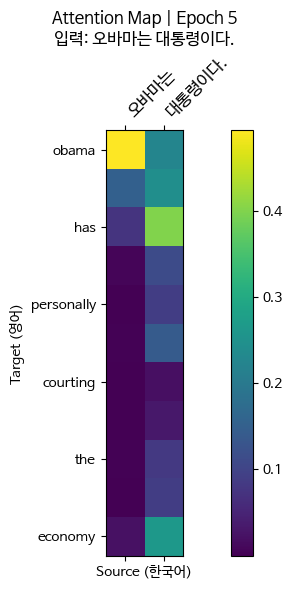

Attention Map 저장: /home/jovyan/work/kor_eng_translation/attention_epoch5.png


Epoch 6: 100%|██████████| 1127/1127 [10:25<00:00,  1.80it/s, loss=3.1974]



[Epoch 6/30]  Train Loss: 3.1915
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama has been campaigning to clinton s democratic party , which is being held in washington . <end>
  입력: 시민들은 도시 속에 산다.
  번역: the dow is down points . <end>
  입력: 커피는 필요 없다.
  번역: the dow is down points . <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: thousands of people killed in the insurgency . <end>
--------------------------------------------------


Epoch 7: 100%|██████████| 1127/1127 [10:24<00:00,  1.80it/s, loss=3.2182]



[Epoch 7/30]  Train Loss: 3.0414
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama leads clinton to drop in the overall popular vote . <end>
  입력: 시민들은 도시 속에 산다.
  번역: the overanalytical carrie was closed . <end>
  입력: 커피는 필요 없다.
  번역: why don t read the issue . <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: thousands of people have killed in the blast . <end>
--------------------------------------------------


...


[Epoch 8/30]  Train Loss: 2.9228
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama forcefully , clinton , obama campaign <end>
  입력: 시민들은 도시 속에 산다.
  번역: the people were thirsty in the city of miryang . <end>
  입력: 커피는 필요 없다.
  번역: why don t forget the right course . <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: thousands of people were killed in the blast , killing thousands of people , the associated press reported . <end>
--------------------------------------------------


Epoch 9: 100%|██████████| 1127/1127 [10:25<00:00,  1.80it/s, loss=3.0497]



[Epoch 9/30]  Train Loss: 2.8220
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama is aiming to illinois his resignation . <end>
  입력: 시민들은 도시 속에 산다.
  번역: maybe you have to drive out of your water ? <end>
  입력: 커피는 필요 없다.
  번역: i don t think that it is not a problem . <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: two people were killed and another were wounded in the attack . <end>
--------------------------------------------------


Epoch 10: 100%|██████████| 1127/1127 [10:24<00:00,  1.80it/s, loss=2.8602]
/tmp/ipykernel_756/2099579019.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""] + src_tokens, rotation=45, ha="left", fontproperties=fp)
/tmp/ipykernel_756/2099579019.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + trg_tokens)



[Epoch 10/30]  Train Loss: 2.7376
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama s campaign has been campaigning for obama s delegates to declare a new president . <end>
  입력: 시민들은 도시 속에 산다.
  번역: maybe you get off ? <end>
  입력: 커피는 필요 없다.
  번역: . <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: seven people were killed and thousands of people in the capital . <end>
--------------------------------------------------


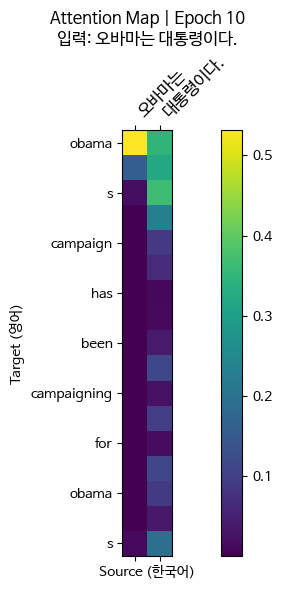

Attention Map 저장: /home/jovyan/work/kor_eng_translation/attention_epoch10.png


Epoch 11: 100%|██████████| 1127/1127 [10:25<00:00,  1.80it/s, loss=2.7457]



[Epoch 11/30]  Train Loss: 2.6641
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama leads clinton in the overall delegate count , and the clinton campaign is in favor of obama . <end>
  입력: 시민들은 도시 속에 산다.
  번역: the city s urban renewal initiative has been relatively mild . <end>
  입력: 커피는 필요 없다.
  번역: . <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: seven people were killed and another tsunami triggered by the tsunami warning . <end>
--------------------------------------------------


Epoch 12: 100%|██████████| 1127/1127 [10:25<00:00,  1.80it/s, loss=2.6654]



[Epoch 12/30]  Train Loss: 2.5978
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama s campaign marks the first time in a vote . <end>
  입력: 시민들은 도시 속에 산다.
  번역: maybe you ve got stranded in the city . <end>
  입력: 커피는 필요 없다.
  번역: we don t think that . <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: thousands of people killed in americus in . <end>
--------------------------------------------------


...


[Epoch 13/30]  Train Loss: 2.5408
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama was responding to obama s appeals town . <end>
  입력: 시민들은 도시 속에 산다.
  번역: you feel like you can t hurt the water . <end>
  입력: 커피는 필요 없다.
  번역: ex i don t read . <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: two people dead and wounded others . <end>
--------------------------------------------------


Epoch 14: 100%|██████████| 1127/1127 [10:25<00:00,  1.80it/s, loss=2.7171]



[Epoch 14/30]  Train Loss: 2.4890
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama is delegates to obama s rival . <end>
  입력: 시민들은 도시 속에 산다.
  번역: angry letters give up to the streets . <end>
  입력: 커피는 필요 없다.
  번역: . <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: the death toll occurred . <end>
--------------------------------------------------


Epoch 15: 100%|██████████| 1127/1127 [10:24<00:00,  1.80it/s, loss=2.7142]
/tmp/ipykernel_756/2099579019.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""] + src_tokens, rotation=45, ha="left", fontproperties=fp)
/tmp/ipykernel_756/2099579019.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + trg_tokens)



[Epoch 15/30]  Train Loss: 2.4397
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama has countered his economic growth in the face of the obama campaign . <end>
  입력: 시민들은 도시 속에 산다.
  번역: the city of pyeongchang was sent to the evacuation zone . <end>
  입력: 커피는 필요 없다.
  번역: why don t exist . <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: seven people were killed and thousands of displaced injured . <end>
--------------------------------------------------


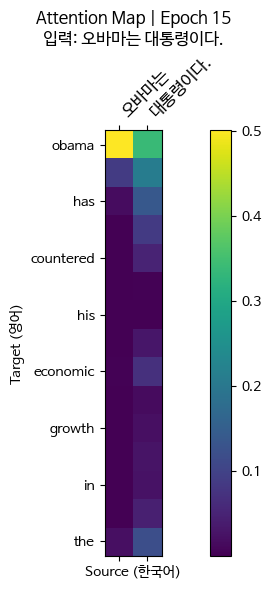

Attention Map 저장: /home/jovyan/work/kor_eng_translation/attention_epoch15.png


Epoch 16: 100%|██████████| 1127/1127 [10:25<00:00,  1.80it/s, loss=2.5576]



[Epoch 16/30]  Train Loss: 2.3952
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama was in tyler , texas . <end>
  입력: 시민들은 도시 속에 산다.
  번역: the minute countryside was almost damaged by a sea dragon . <end>
  입력: 커피는 필요 없다.
  번역: . <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: two people were killed and another were injured . <end>
--------------------------------------------------


Epoch 17: 100%|██████████| 1127/1127 [10:24<00:00,  1.80it/s, loss=2.5302]



[Epoch 17/30]  Train Loss: 2.3535
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama was leading obama in vermont , illinois . <end>
  입력: 시민들은 도시 속에 산다.
  번역: the urban areas of both black and water <end>
  입력: 커피는 필요 없다.
  번역: don t be confused . <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: thousands of people were killed . <end>
--------------------------------------------------


...


[Epoch 18/30]  Train Loss: 2.3137
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama has mentioned his support for clinton s lead in pledged delegates . <end>
  입력: 시민들은 도시 속에 산다.
  번역: you can t keep a string of time . <end>
  입력: 커피는 필요 없다.
  번역: don t read coffee ! <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: two people were killed and another tsunami triggered by a tsunami . <end>
--------------------------------------------------


Epoch 19: 100%|██████████| 1127/1127 [10:24<00:00,  1.81it/s, loss=2.3890]



[Epoch 19/30]  Train Loss: 2.2781
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama has been courting in the democratic caucuses . <end>
  입력: 시민들은 도시 속에 산다.
  번역: you feel like the truman . <end>
  입력: 커피는 필요 없다.
  번역: you don t want to be a little bit <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: seven people were killed in the blast . <end>
--------------------------------------------------


Epoch 20: 100%|██████████| 1127/1127 [10:24<00:00,  1.80it/s, loss=2.3374]
/tmp/ipykernel_756/2099579019.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""] + src_tokens, rotation=45, ha="left", fontproperties=fp)
/tmp/ipykernel_756/2099579019.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + trg_tokens)



[Epoch 20/30]  Train Loss: 2.2445
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama has been courting edwards in the obama campaign . <end>
  입력: 시민들은 도시 속에 산다.
  번역: the city of pyeongchang followed the weekend . <end>
  입력: 커피는 필요 없다.
  번역: . <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: seven people were killed and another were injured . <end>
--------------------------------------------------


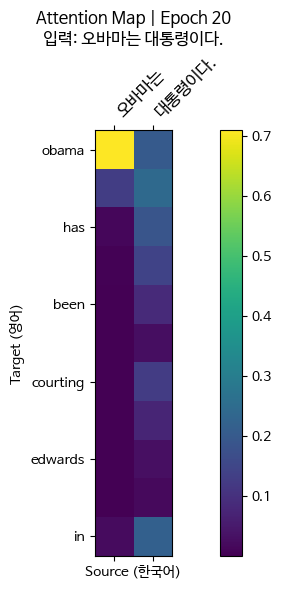

Attention Map 저장: /home/jovyan/work/kor_eng_translation/attention_epoch20.png


Epoch 21: 100%|██████████| 1127/1127 [10:24<00:00,  1.80it/s, loss=2.2564]



[Epoch 21/30]  Train Loss: 2.2129
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama has been courting edwards in the obama campaign . <end>
  입력: 시민들은 도시 속에 산다.
  번역: the protesters are calling for the people to walk through the streets . <end>
  입력: 커피는 필요 없다.
  번역: . <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: two soldiers were killed in the bombing . <end>
--------------------------------------------------


Epoch 22: 100%|██████████| 1127/1127 [10:24<00:00,  1.80it/s, loss=2.3619]



[Epoch 22/30]  Train Loss: 2.1809
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama s camp touted as a . <end>
  입력: 시민들은 도시 속에 산다.
  번역: the city block the streets around the city . <end>
  입력: 커피는 필요 없다.
  번역: don t read ! <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: roughly seven people were killed and another were injured . <end>
--------------------------------------------------


...


[Epoch 23/30]  Train Loss: 2.1518
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama s campaign was separated from obama . <end>
  입력: 시민들은 도시 속에 산다.
  번역: roads are busy in the city of downtown coffee . <end>
  입력: 커피는 필요 없다.
  번역: keeping track of the world ? <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: seven people were killed and thousands of people were killed . <end>
--------------------------------------------------


Epoch 24: 100%|██████████| 1127/1127 [10:24<00:00,  1.80it/s, loss=2.2839]



[Epoch 24/30]  Train Loss: 2.1228
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama has been courting edwards in the obama campaign . <end>
  입력: 시민들은 도시 속에 산다.
  번역: roads were in the dark . <end>
  입력: 커피는 필요 없다.
  번역: you don t want to read the written today . <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: seven people were killed and more than , people . <end>
--------------------------------------------------


Epoch 25: 100%|██████████| 1127/1127 [10:24<00:00,  1.81it/s, loss=2.1634]
/tmp/ipykernel_756/2099579019.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""] + src_tokens, rotation=45, ha="left", fontproperties=fp)
/tmp/ipykernel_756/2099579019.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + trg_tokens)



[Epoch 25/30]  Train Loss: 2.0964
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama has vastly outraised mccain s rival . <end>
  입력: 시민들은 도시 속에 산다.
  번역: you feel good ! <end>
  입력: 커피는 필요 없다.
  번역: . <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: seven people were killed and thousands of injured in the temblor . <end>
--------------------------------------------------


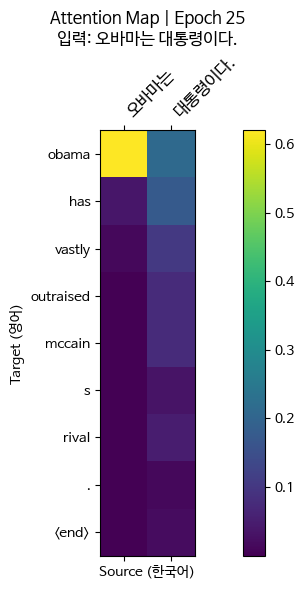

Attention Map 저장: /home/jovyan/work/kor_eng_translation/attention_epoch25.png


Epoch 26: 100%|██████████| 1127/1127 [10:23<00:00,  1.81it/s, loss=2.2046]



[Epoch 26/30]  Train Loss: 2.0718
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama was responding to obama s campaign . <end>
  입력: 시민들은 도시 속에 산다.
  번역: you feel like you . <end>
  입력: 커피는 필요 없다.
  번역: you can t take a few times . <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: seven deaths occurred in the provincial capital . <end>
--------------------------------------------------


Epoch 27: 100%|██████████| 1127/1127 [10:23<00:00,  1.81it/s, loss=2.2112]



[Epoch 27/30]  Train Loss: 2.0466
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama has vastly outraised obama in his talented . <end>
  입력: 시민들은 도시 속에 산다.
  번역: roads have turned into the streets of the ayoub . <end>
  입력: 커피는 필요 없다.
  번역: you don t want to be one of the most exciting . <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: seven coastal areas of the cantaloupe . <end>
--------------------------------------------------


...


[Epoch 28/30]  Train Loss: 2.0231
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama was responding to obama s campaign trail . <end>
  입력: 시민들은 도시 속에 산다.
  번역: you feel bad ! <end>
  입력: 커피는 필요 없다.
  번역: skip coffee isn t <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: seven people were killed and injured in the aftermath of the worst tsunami . <end>
--------------------------------------------------


Epoch 29: 100%|██████████| 1127/1127 [10:23<00:00,  1.81it/s, loss=2.0812]



[Epoch 29/30]  Train Loss: 2.0007
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama was responding to the idea of the obama campaign . <end>
  입력: 시민들은 도시 속에 산다.
  번역: roads shook the city of pyeongchang in the street . <end>
  입력: 커피는 필요 없다.
  번역: don t read coffee ! <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: seven deaths were killed in the blast . <end>
--------------------------------------------------


Epoch 30: 100%|██████████| 1127/1127 [10:23<00:00,  1.81it/s, loss=2.1975]
/tmp/ipykernel_756/2099579019.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""] + src_tokens, rotation=45, ha="left", fontproperties=fp)
/tmp/ipykernel_756/2099579019.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + trg_tokens)



[Epoch 30/30]  Train Loss: 1.9805
--------------------------------------------------
  입력: 오바마는 대통령이다.
  번역: obama has vastly outraised mccain s rally in the obama . <end>
  입력: 시민들은 도시 속에 산다.
  번역: roads like the city of pyeongchang in the street <end>
  입력: 커피는 필요 없다.
  번역: why don t exist . <end>
  입력: 일곱 명의 사망자가 발생했다.
  번역: seven deaths were killed in the fighting . <end>
--------------------------------------------------


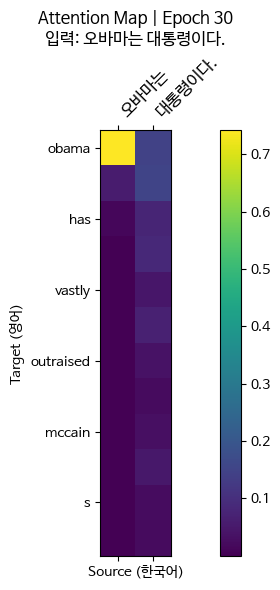

Attention Map 저장: /home/jovyan/work/kor_eng_translation/attention_epoch30.png


In [10]:
EPOCHS    = 30
loss_hist = []

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    loss_hist.append(train_loss)
    scheduler.step(train_loss)
    print(f"\n[Epoch {epoch+1}/{EPOCHS}]  Train Loss: {train_loss:.4f}")
    print("-" * 50)
    for sent in TEST_SENTENCES:
        trans, _, _ = evaluate_sentence(sent, model)
        print(f"  입력: {sent}")
        print(f"  번역: {trans}")
    print("-" * 50)
    # 5 에폭마다 Attention Map 저장
    if (epoch + 1) % 5 == 0:
        t, s_tok, a = evaluate_sentence(TEST_SENTENCES[0], model)
        show_attention(TEST_SENTENCES[0], t, s_tok, a, epoch + 1)


## Step 9. 학습 곡선 시각화

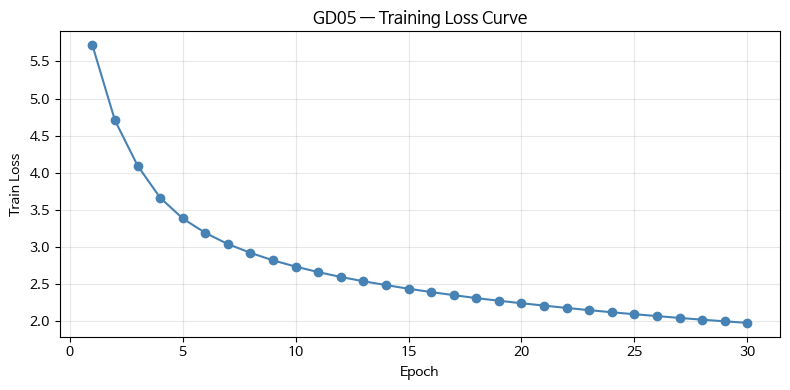

Loss 그래프 저장: /home/jovyan/work/kor_eng_translation/training_loss.png


In [11]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), loss_hist, marker="o", linewidth=1.5, color="steelblue")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("GD05 — Training Loss Curve")
plt.grid(True, alpha=0.3)
plt.tight_layout()
loss_img = os.path.join(DATA_DIR, "training_loss.png")
plt.savefig(loss_img, dpi=100)
plt.show()
print(f"Loss 그래프 저장: {loss_img}")


## Step 10. 모델 저장

In [12]:
model_path = os.path.join(DATA_DIR, "GD05_seq2seq_kor_eng.pt")
torch.save({
    "model_state": model.state_dict(),
    "kor_vocab":   kor_vocab,
    "eng_vocab":   eng_vocab,
}, model_path)
print(f"모델 저장 완료: {model_path}")


모델 저장 완료: /home/jovyan/work/kor_eng_translation/GD05_seq2seq_kor_eng.pt


## Step 11. 최종 번역 결과 

GD05 — 최종 번역 결과
  입력: 오바마는 대통령이다.
  번역: obama has vastly outraised mccain s rally in the obama . <end>

  입력: 시민들은 도시 속에 산다.
  번역: roads like the city of pyeongchang in the street <end>

  입력: 커피는 필요 없다.
  번역: why don t exist . <end>

  입력: 일곱 명의 사망자가 발생했다.
  번역: seven deaths were killed in the fighting . <end>



/tmp/ipykernel_756/2099579019.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""] + src_tokens, rotation=45, ha="left", fontproperties=fp)
/tmp/ipykernel_756/2099579019.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + trg_tokens)


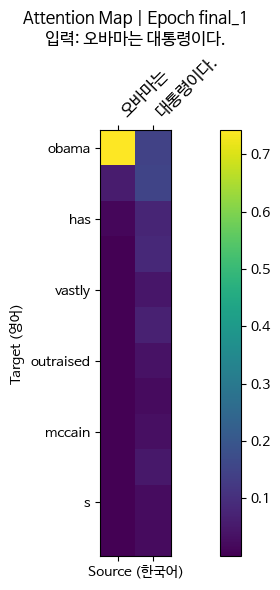

Attention Map 저장: /home/jovyan/work/kor_eng_translation/attention_epochfinal_1.png


/tmp/ipykernel_756/2099579019.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""] + src_tokens, rotation=45, ha="left", fontproperties=fp)
/tmp/ipykernel_756/2099579019.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + trg_tokens)


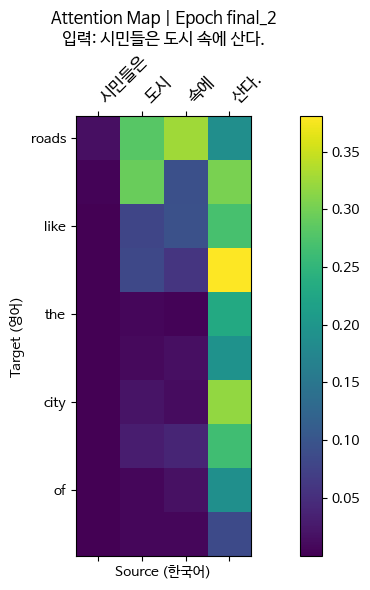

Attention Map 저장: /home/jovyan/work/kor_eng_translation/attention_epochfinal_2.png


/tmp/ipykernel_756/2099579019.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""] + src_tokens, rotation=45, ha="left", fontproperties=fp)
/tmp/ipykernel_756/2099579019.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + trg_tokens)


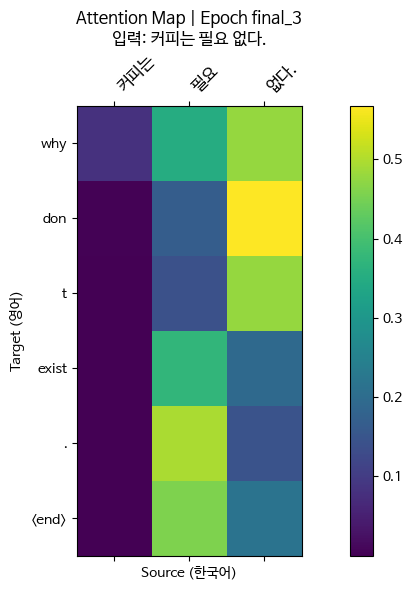

Attention Map 저장: /home/jovyan/work/kor_eng_translation/attention_epochfinal_3.png


/tmp/ipykernel_756/2099579019.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""] + src_tokens, rotation=45, ha="left", fontproperties=fp)
/tmp/ipykernel_756/2099579019.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + trg_tokens)


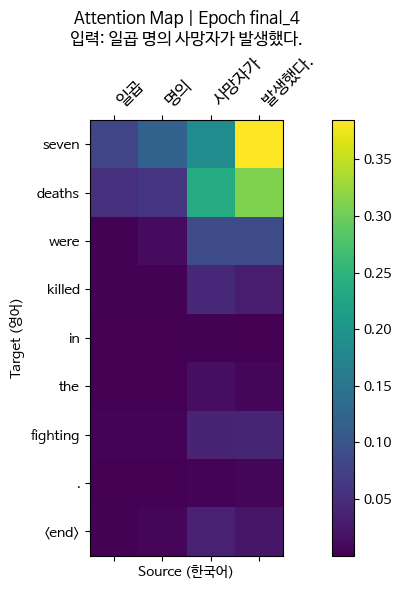

Attention Map 저장: /home/jovyan/work/kor_eng_translation/attention_epochfinal_4.png


In [13]:
print("=" * 60)
print("GD05 — 최종 번역 결과")
print("=" * 60)
for sent in TEST_SENTENCES:
    trans, src_tok, attn = evaluate_sentence(sent, model)
    print(f"  입력: {sent}")
    print(f"  번역: {trans}")
    print()

# Attention Map (최종)
for i, sent in enumerate(TEST_SENTENCES):
    trans, src_tok, attn = evaluate_sentence(sent, model)
    show_attention(sent, trans, src_tok, attn, epoch=f"final_{i+1}")


# 회고
### 이번 실험에서는 한국어-영어 병렬 뉴스 말뭉치(korean-parallel-corpora)를 활용하여 Bahdanau Attention 기반 GRU Encoder-Decoder Seq2Seq 모델로 한국어→영어 번역기를 구현하였으며, 한국어 토크나이저로는 KoNLPy MeCab을, Embedding Size 256, Hidden Size 512, Dropout 0.3, 30 에폭 학습을 적용하였습니다. 실험 결과 Training Loss가 5.7에서 2.0까지 안정적으로 수렴하였고, "일곱 명의 사망자가 발생했다 → seven deaths were killed in the fighting"처럼 의미가 전달되는 번역이 생성되었으며 Attention Map에서도 한국어 형태소와 영어 단어 간 대응 관계가 시각적으로 확인되는 등 학습 파이프라인이 정상적으로 동작했습니다. 하지만 "오바마는 대통령이다 → obama has vastly outraised mccain…"처럼 뉴스 도메인 편향으로 인해 단순 문장에서도 선거 기사 패턴이 그대로 생성되고 Greedy Decoding의 한계로 문법적으로 어색한 번역이 나타나기도 했습니다. 